Objetivo:
Previsão de Preços de Casas

### Crie um dataset único a partir dos datasets em anexo.

### 1. Análise e entendimento dos dados
- Explique o que representam as principais variáveis.
- Mostre correlações, outliers e padrões relevantes.
- Descreva como combinou os dados físicos e demográficos.

### 2. Desenvolvimento do modelo de Machine Learning
Inclua:
- **a. Variáveis importantes:** quais features foram mais relevantes e por quê.
- **b. Escolha do modelo:** escolha e implemente um modelo para resolver o problema --- Lembre-se que a NP1 englobou até MLP.
- **c. Generalização:** como você garante que o modelo generaliza bem para novos dados (ex: uso de *train/test split*, *cross-validation*, regularização, etc.).

O aluno deve entregar um relatório explicando os passos solicitados e o código contando todas as etapas de EDA, Pré-Processamento, Implementação do Modelo.

In [32]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.callbacks import EarlyStopping



In [33]:
df_demog = pd.read_csv('zipcode_demographics.csv', delimiter=',')
df_house = pd.read_csv('kc_house_data.csv', delimiter=',')
df_future = pd.read_csv('future_unseen_examples.csv', delimiter=',')

df = df_house.merge(df_demog, on='zipcode', how='left')
df.to_csv('dataframe.csv', index=False)

print(df.shape)
print(df.isnull().sum())
print(df.describe())

(21613, 47)
id                        0
date                      0
price                     0
bedrooms                  0
bathrooms                 0
sqft_living               0
sqft_lot                  0
floors                    0
waterfront                0
view                      0
condition                 0
grade                     0
sqft_above                0
sqft_basement             0
yr_built                  0
yr_renovated              0
zipcode                   0
lat                       0
long                      0
sqft_living15             0
sqft_lot15                0
ppltn_qty                 0
urbn_ppltn_qty            0
sbrbn_ppltn_qty           0
farm_ppltn_qty            0
non_farm_qty              0
medn_hshld_incm_amt       0
medn_incm_per_prsn_amt    0
hous_val_amt              0
edctn_less_than_9_qty     0
edctn_9_12_qty            0
edctn_high_schl_qty       0
edctn_some_clg_qty        0
edctn_assoc_dgre_qty      0
edctn_bchlr_dgre_qty      0
edctn_pr

In [34]:
# renovated: True / False
df['renovated'] = df['yr_renovated'] > 0
# month
df['month_sold'] = df['date'].str[4:6].astype(int)
# age
df['yr_sold'] = df['date'].str[:4].astype(int)
df['age'] = df['yr_sold'] - df['yr_built']
# basement: True / False
df['basement'] = df['sqft_basement'] > 0
# diferença entre a regiao
df['dif_sqft_living'] = df['sqft_living'] - df['sqft_living15']
df['dif_sqft_lot'] = df['sqft_lot'] - df['sqft_lot15']

print(df.head)

<bound method NDFrame.head of                id             date     price  bedrooms  bathrooms  \
0      7129300520  20141013T000000  221900.0         3       1.00   
1      6414100192  20141209T000000  538000.0         3       2.25   
2      5631500400  20150225T000000  180000.0         2       1.00   
3      2487200875  20141209T000000  604000.0         4       3.00   
4      1954400510  20150218T000000  510000.0         3       2.00   
...           ...              ...       ...       ...        ...   
21608   263000018  20140521T000000  360000.0         3       2.50   
21609  6600060120  20150223T000000  400000.0         4       2.50   
21610  1523300141  20140623T000000  402101.0         2       0.75   
21611   291310100  20150116T000000  400000.0         3       2.50   
21612  1523300157  20141015T000000  325000.0         2       0.75   

       sqft_living  sqft_lot  floors  waterfront  view  ...  per_assoc  \
0             1180      5650     1.0           0     0  ...        

In [35]:
# removendo o que não interessa ou causa data leakage ou foi substituído/informação duplicada
df.drop(columns=['date', 'sqft_living15', 'sqft_lot15', 'zipcode', 'hous_val_amt', 'id', 'yr_renovated'], inplace=True)
print(df.shape)
print(df.isnull().sum())

(21613, 47)
price                     0
bedrooms                  0
bathrooms                 0
sqft_living               0
sqft_lot                  0
floors                    0
waterfront                0
view                      0
condition                 0
grade                     0
sqft_above                0
sqft_basement             0
yr_built                  0
lat                       0
long                      0
ppltn_qty                 0
urbn_ppltn_qty            0
sbrbn_ppltn_qty           0
farm_ppltn_qty            0
non_farm_qty              0
medn_hshld_incm_amt       0
medn_incm_per_prsn_amt    0
edctn_less_than_9_qty     0
edctn_9_12_qty            0
edctn_high_schl_qty       0
edctn_some_clg_qty        0
edctn_assoc_dgre_qty      0
edctn_bchlr_dgre_qty      0
edctn_prfsnl_qty          0
per_urbn                  0
per_sbrbn                 0
per_farm                  0
per_non_farm              0
per_less_than_9           0
per_9_to_12               0
per_hsd 

In [36]:
# outliers
detectar_outlier = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'sqft_above',
    'sqft_basement',
    'medn_hshld_incm_amt',
    'medn_incm_per_prsn_amt',
    'dif_sqft_living',
    'dif_sqft_lot',
]
df_outlier = df[detectar_outlier]

z_scores = np.abs((df_outlier - df_outlier.mean()) / df_outlier.std())
outliers = (z_scores > 3)
print(outliers.sum())
df_outlier[outliers].to_csv('outliers_zscore.csv', index=False)
print(df_outlier[outliers].describe())

print('\n')

Q1 = df_outlier.quantile(0.25)
Q3 = df_outlier.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_outlier < (Q1 - 1.5 * IQR)) | (df_outlier > (Q3 + 1.5 * IQR)))
print(outliers.sum())
df_outlier[outliers].to_csv('outliers_iqr.csv', index=False)
print(df_outlier[outliers].describe())

price                     406
bedrooms                   75
bathrooms                 187
sqft_living               248
sqft_lot                  347
sqft_above                254
sqft_basement             247
medn_hshld_incm_amt        50
medn_incm_per_prsn_amt     50
dif_sqft_living           340
dif_sqft_lot              244
dtype: int64
              price   bedrooms   bathrooms   sqft_living      sqft_lot  \
count  4.060000e+02  75.000000  187.000000    248.000000  3.470000e+02   
mean   2.276499e+06   6.640000    4.902406   5823.685484  2.716364e+05   
std    7.685827e+05   4.323537    0.663088   1120.504588  1.687333e+05   
min    1.646000e+06   0.000000    4.500000   4850.000000  1.393920e+05   
25%    1.791212e+06   7.000000    4.500000   5127.500000  1.995965e+05   
50%    2.000000e+06   7.000000    4.500000   5480.000000  2.178000e+05   
75%    2.496250e+06   8.000000    5.000000   6070.000000  2.697905e+05   
max    7.700000e+06  33.000000    8.000000  13540.000000  1.65135

In [37]:
# removendo outlier de 'bedrooms' por KNN
df.loc[df['bedrooms'] == 33, 'bedrooms'] = np.nan
imputer = KNNImputer(n_neighbors=5)
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

                           price
price                   1.000000
sqft_living             0.702035
grade                   0.667434
sqft_above              0.605567
medn_incm_per_prsn_amt  0.549911
bathrooms               0.525138
per_prfsnl              0.500262
per_bchlr               0.474896
dif_sqft_living         0.405392
view                    0.397293
sqft_basement           0.323816
bedrooms                0.315434
lat                     0.307003
edctn_prfsnl_qty        0.291694
medn_hshld_incm_amt     0.272460
waterfront              0.266369
floors                  0.256794
edctn_bchlr_dgre_qty    0.209238
basement                0.180230
renovated               0.126092
sqft_lot                0.089661
per_urbn                0.068983
yr_built                0.054012
dif_sqft_lot            0.050591
condition               0.036362
long                    0.021626
yr_sold                 0.003576
month_sold             -0.010081
per_sbrbn              -0.023602
sbrbn_pplt

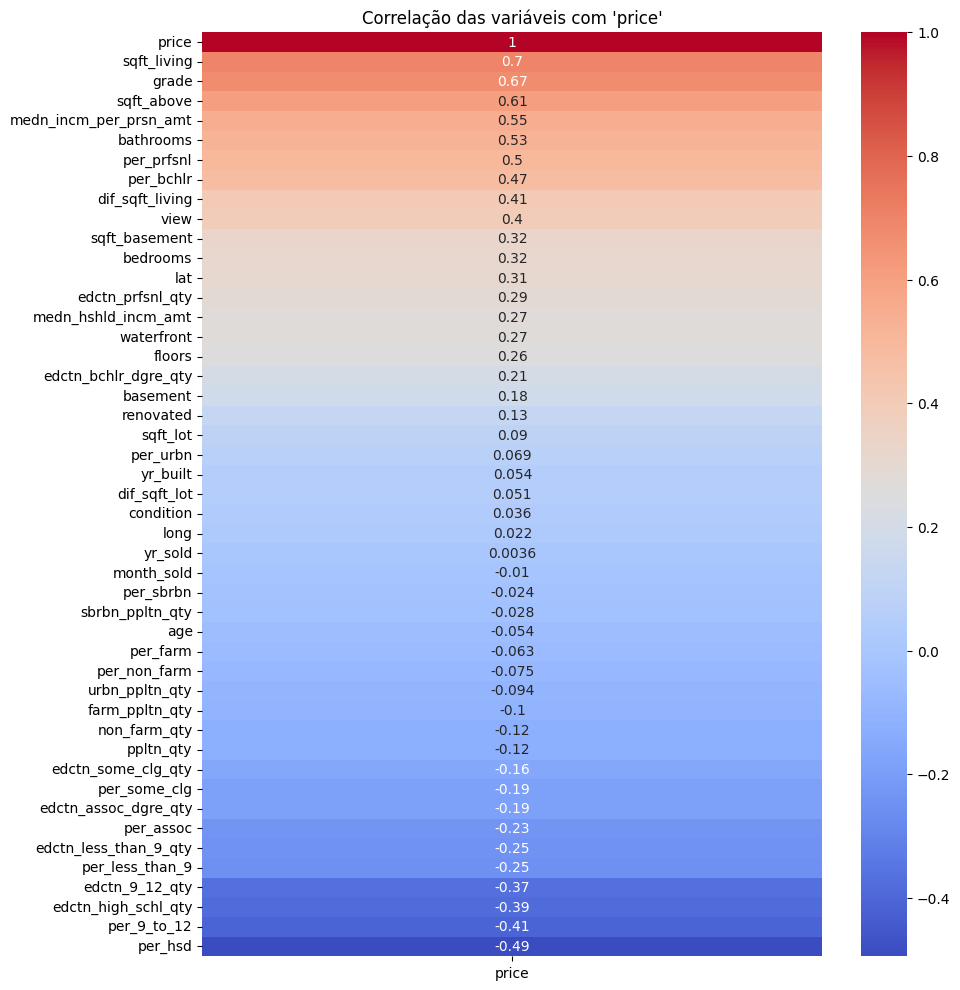

In [38]:
# correlação
price_corr = df.corr(numeric_only=True)[['price']].sort_values(by='price', ascending=False)
print(price_corr)

plt.figure(figsize=(10,12))
sns.heatmap(price_corr, annot=True, cmap='coolwarm')
plt.title("Correlação das variáveis com 'price'")
plt.show()


In [39]:
# features
features = [
    "sqft_living",
    "grade",
    "sqft_above",
    "medn_incm_per_prsn_amt",
    "bathrooms",
    "per_prfsnl",
    "per_bchlr",
    "dif_sqft_living",
    "view",
    "sqft_basement",
    "bedrooms",
    "lat",
    "medn_hshld_incm_amt",
    "waterfront",
    "floors",
    "basement",
    "renovated",
    "sqft_lot",
    "per_urbn",
    "dif_sqft_lot",
    "condition",
    "long",
    "age",
    "per_assoc",
    "per_9_to_12",
    "per_hsd"
    ]

X = df[features]
y = df['price']

In [40]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
# normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

### Escolha do modelo

Modelos lineares foram descartados pela natureza não-linear das relações entre área, localização e preço. O MLP é o modelo mais complexo dentro do escopo estudado e é tecnicamente adequado para o problema.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 165134254080.0000 - mae: 262582.8438 - val_loss: 80960937984.0000 - val_mae: 200821.7656
Epoch 2/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 93023330304.0000 - mae: 188357.5938 - val_loss: 57547427840.0000 - val_mae: 164179.6562
Epoch 3/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 62866493440.0000 - mae: 147348.3594 - val_loss: 37937868800.0000 - val_mae: 124629.4219
Epoch 4/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49716285440.0000 - mae: 132713.0156 - val_loss: 34570428416.0000 - val_mae: 120049.7656
Epoch 5/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45800058880.0000 - mae: 128689.2734 - val_loss: 33579728896.0000 - val_mae: 118404.2812
Epoch 6/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 43823157248.0000 - mae: 126459.4766 - val_loss: 33005875200.0000 - val_mae: 116546.9766
Epoch 7/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 42425245696.0000 - mae: 124759.6328 - v

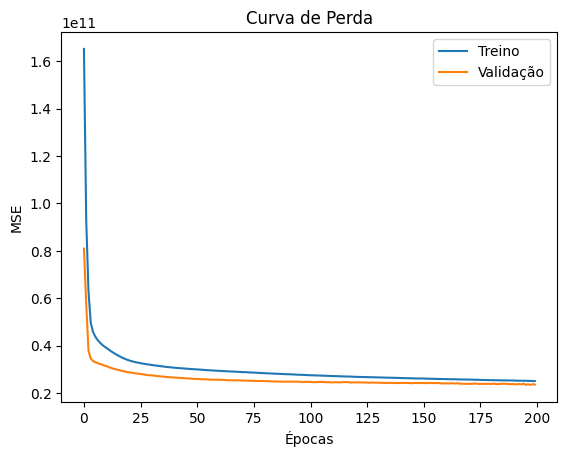

In [50]:
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),

])

print(model.summary())

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, mae = model.evaluate(X_test, y_test)
print(f'MAE: ${mae:,.0f}')

y_pred = model.predict(X_test).flatten()

from sklearn.metrics import r2_score
print(f'R²: {r2_score(y_test, y_pred):.4f}')

plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Curva de Perda')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.show()